In [1]:
import numpy as np
import pandas as pd
import re
import sweetviz as sv
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook"


pio.templates["compact"] = pio.templates["plotly"].update({
    "layout": {"autosize": False, "width": 500, "height": 400}
})
pio.templates.default = "compact"

import warnings as wr
wr.filterwarnings("ignore")

f:\Grv\Grv\05 GIT\14_Proj_ML_99Acres\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("data/07_flats_EDA.csv")

In [3]:
df.shape

(2904, 32)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2904 entries, 0 to 2903
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   area_sqm                2904 non-null   float64
 1   bedroom                 2904 non-null   float64
 2   bathroom                2904 non-null   float64
 3   balcony                 2904 non-null   float64
 4   addl_room               2904 non-null   float64
 5   sector                  2904 non-null   object 
 6   landmark_count          2904 non-null   float64
 7   has_hospital_or_clinic  2904 non-null   float64
 8   has_police_stn          2904 non-null   float64
 9   has_fire_stn            2904 non-null   float64
 10  has_mall                2904 non-null   float64
 11  has_market              2904 non-null   float64
 12  has_park                2904 non-null   float64
 13  has_bank_or_atm         2904 non-null   float64
 14  has_institute           2904 non-null   

In [5]:
df.head(2)

,area_sqm,bedroom,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
0,83.61,2.0,2.0,1.0,0.0,sector 7,50.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,carpet,mid,new,maa bhagwati residency,gurgaon,0.765
1,60.39,2.0,2.0,1.0,0.0,sector 3,48.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,carpet,low,old,apna enclave,gurgaon,0.850


In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
area_sqm,2904.0,NaN,NaN,NaN,250.426985,2114.857362,0.6968,120.725,161.14,199.74,68483.2
bedroom,2904.0,NaN,NaN,NaN,2.809229,0.789248,1.0,2.0,3.0,3.0,6.0
bathroom,2904.0,NaN,NaN,NaN,2.967975,1.04333,1.0,2.0,3.0,4.0,7.0
balcony,2904.0,NaN,NaN,NaN,2.462466,0.787411,0.0,2.0,3.0,3.0,3.0
addl_room,2904.0,NaN,NaN,NaN,0.577135,0.494099,0.0,0.0,1.0,1.0,1.0
sector,2904,91,sector 33,213,NaN,NaN,NaN,NaN,NaN,NaN,NaN
landmark_count,2904.0,NaN,NaN,NaN,14.306818,11.395584,3.0,9.0,10.0,14.0,50.0
has_hospital_or_clinic,2904.0,NaN,NaN,NaN,0.801653,0.398824,0.0,1.0,1.0,1.0,1.0
has_police_stn,2904.0,NaN,NaN,NaN,0.014807,0.120801,0.0,0.0,0.0,0.0,1.0
has_fire_stn,2904.0,NaN,NaN,NaN,0.000689,0.026239,0.0,0.0,0.0,0.0,1.0


In [7]:
df.columns

Index(['area_sqm', 'bedroom', 'bathroom', 'balcony', 'addl_room', 'sector',
       'landmark_count', 'has_hospital_or_clinic', 'has_police_stn',
       'has_fire_stn', 'has_mall', 'has_market', 'has_park', 'has_bank_or_atm',
       'has_institute', 'has_airport', 'has_rly_stn', 'has_metro_stn',
       'has_expy', 'has_petrol_pump', 'has_hotel', 'has_temple_or_church',
       'has_famous_chowk', 'has_club', 'has_stadium', 'has_restro_cafe',
       'area_type', 'floor_rise', 'age', 'society', 'city', 'price_cr'],
      dtype='object')

In [8]:
df.isnull().sum()

area_sqm                  0
bedroom                   0
bathroom                  0
balcony                   0
addl_room                 0
sector                    0
landmark_count            0
has_hospital_or_clinic    0
has_police_stn            0
has_fire_stn              0
has_mall                  0
has_market                0
has_park                  0
has_bank_or_atm           0
has_institute             0
has_airport               0
has_rly_stn               0
has_metro_stn             0
has_expy                  0
has_petrol_pump           0
has_hotel                 0
has_temple_or_church      0
has_famous_chowk          0
has_club                  0
has_stadium               0
has_restro_cafe           0
area_type                 0
floor_rise                0
age                       0
society                   0
city                      0
price_cr                  0
dtype: int64

In [9]:
df.dropna(inplace=True)

In [10]:
px.pie(df, names='area_type', title='Count of Area Type', height=500)

In [11]:
px.histogram(df, y='floor_rise', title='Count of Floor Rise', text_auto=True, height=300)

In [12]:
px.sunburst(df, path=["sector", "society"], title='city --> sector --> society', color='city', height=1000, width=800)

In [13]:
px.treemap(df, 
           path=["city", "sector", "society"], 
           height=600, width=1000
)

In [14]:
px.scatter_3d(df,
                x='area_sqm',
                y='bedroom',
                z='price_cr',
                log_y=False,
                color='age',
                hover_name='society',
                 width=1000,
                 height=500)

In [15]:
fig = px.imshow(df.corr(numeric_only=True),
                text_auto=True,
                color_continuous_scale="RdBu_r",
                aspect="auto",
                title="Matrix Heatmap",
               height=500,
               width=1000)
fig.show()

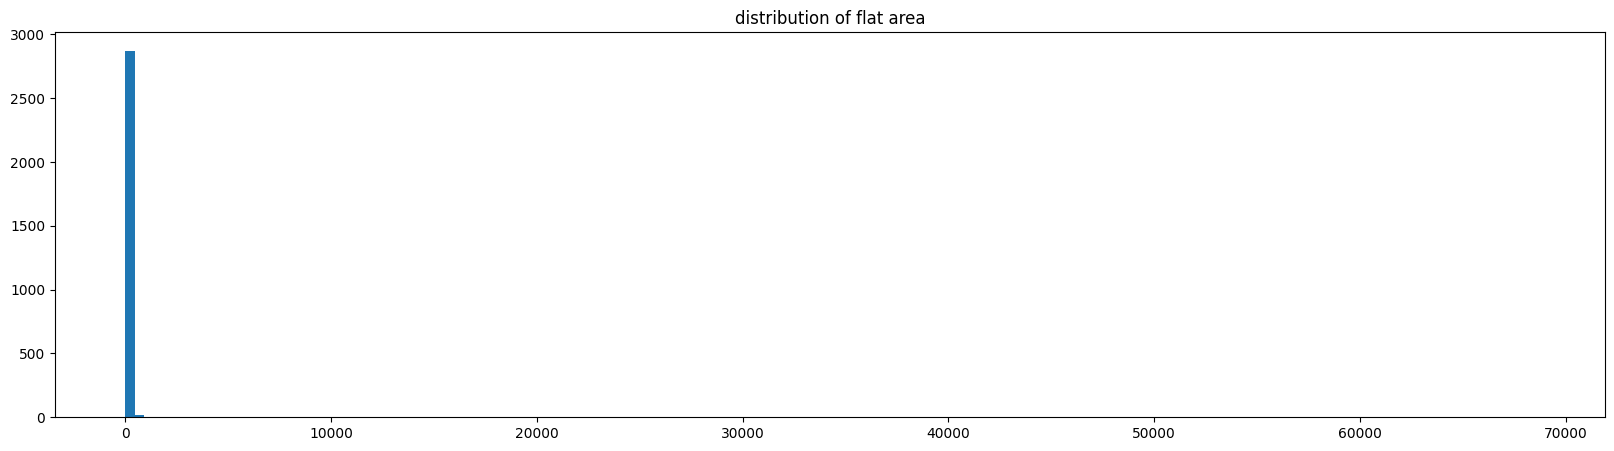

In [16]:
plt.figure(figsize=(20,5))
plt.hist(x=df['area_sqm'], bins=150, log=False)
plt.title("distribution of flat area")
plt.show()

In [17]:
df.columns

Index(['area_sqm', 'bedroom', 'bathroom', 'balcony', 'addl_room', 'sector',
       'landmark_count', 'has_hospital_or_clinic', 'has_police_stn',
       'has_fire_stn', 'has_mall', 'has_market', 'has_park', 'has_bank_or_atm',
       'has_institute', 'has_airport', 'has_rly_stn', 'has_metro_stn',
       'has_expy', 'has_petrol_pump', 'has_hotel', 'has_temple_or_church',
       'has_famous_chowk', 'has_club', 'has_stadium', 'has_restro_cafe',
       'area_type', 'floor_rise', 'age', 'society', 'city', 'price_cr'],
      dtype='object')

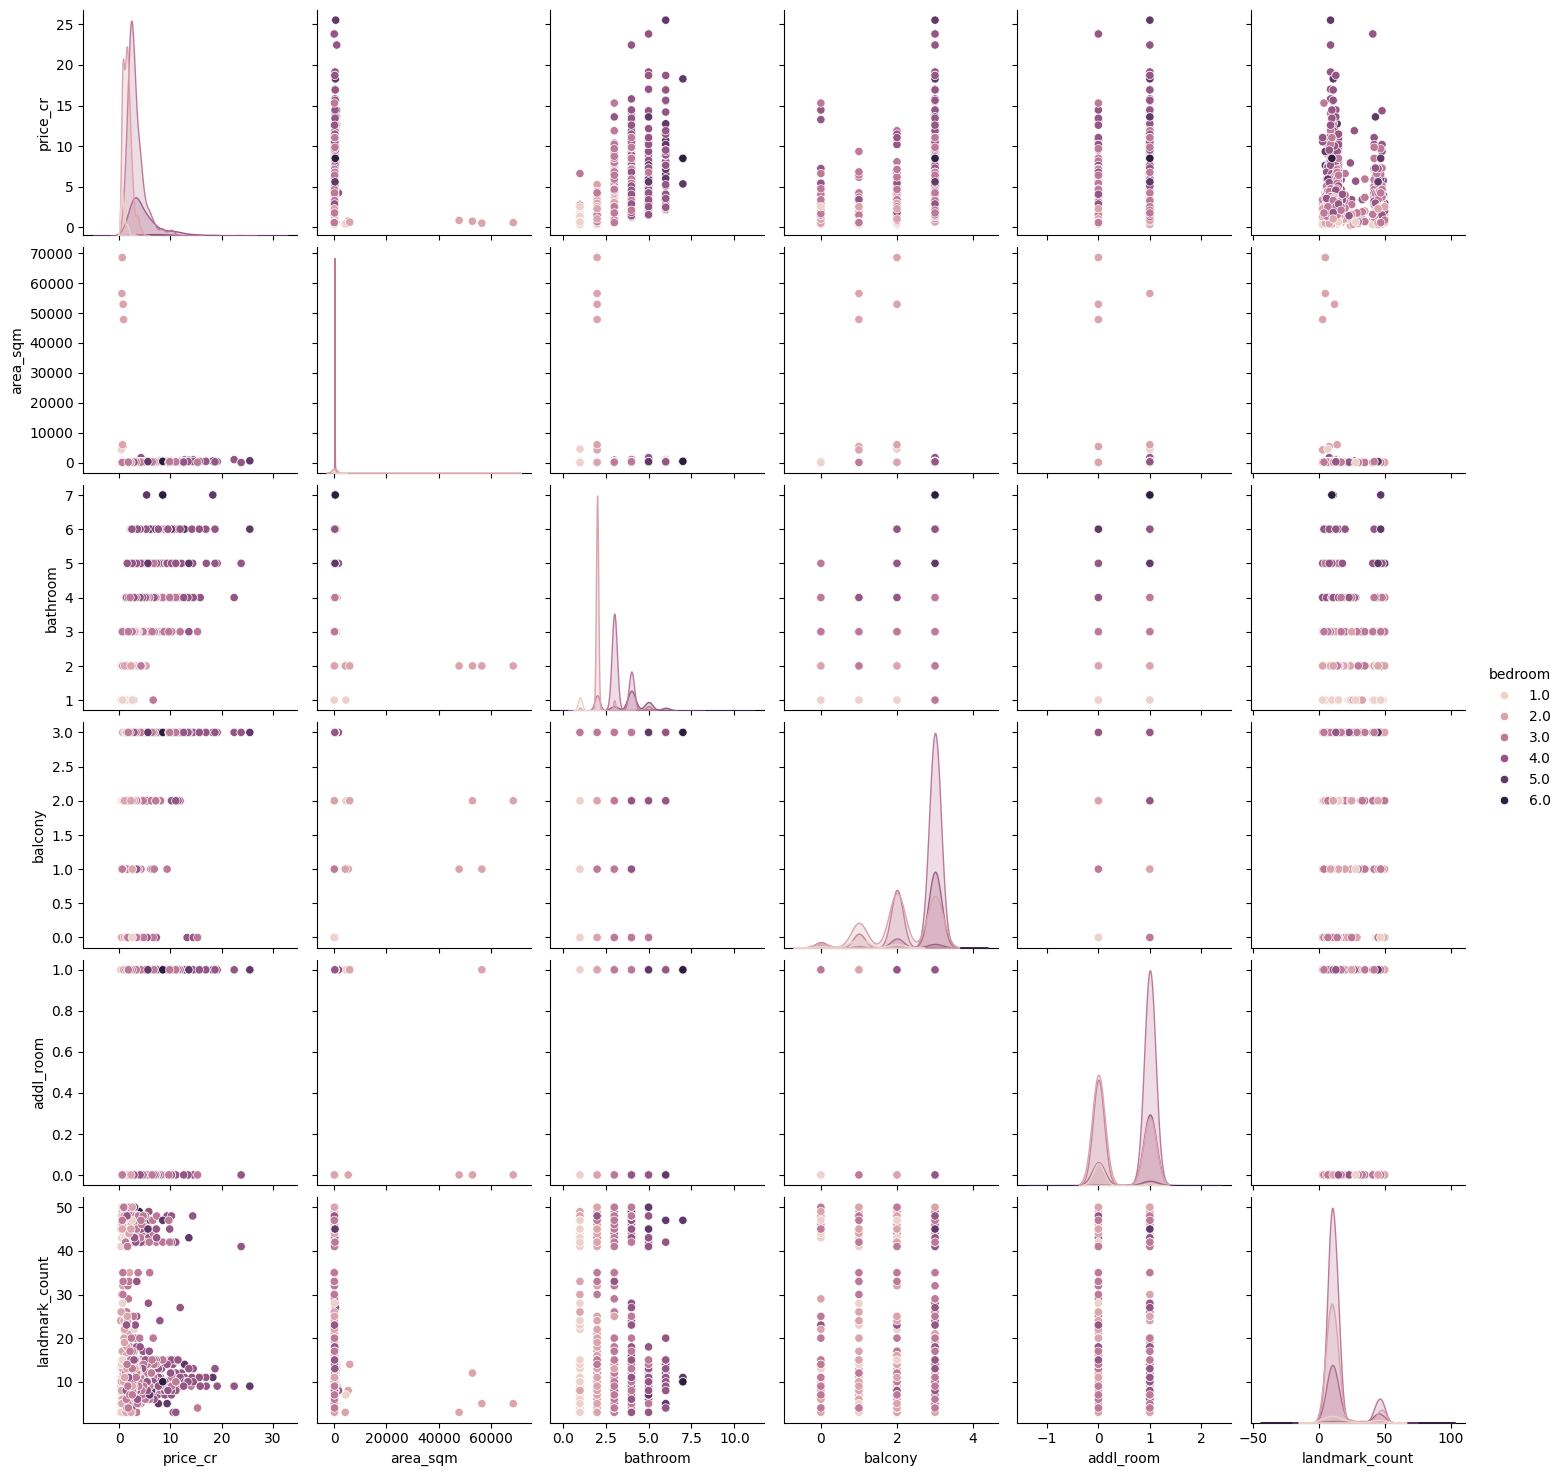

In [18]:
df1 = df[['price_cr', 'area_sqm', 'bedroom', 'bathroom', 'balcony', 'addl_room','landmark_count']]
sns.pairplot(df1, hue='bedroom')

In [19]:
grp_sector_wise = df.groupby(['city','sector'])[['price_cr','area_sqm','bedroom','landmark_count']].mean()
grp_sector_wise = grp_sector_wise.query("city == 'gurgaon'")
grp_sector_wise

price_cr     area_sqm   bedroom  landmark_count
city    sector                                                     
gurgaon sector 1    2.145400   208.290000  3.400000       27.200000
        sector 10   1.813333   146.413333  2.833333       49.166667
        sector 102  2.910369   165.287748  2.837838       12.288288
        sector 103  2.171325   162.012250  2.650000       14.850000
        sector 104  2.767551   182.258755  2.855072       13.507246
...                      ...          ...       ...             ...
        sector 91   2.484267   190.978667  3.133333        9.466667
        sector 92   1.528553   143.259751  3.148936       10.287234
        sector 93   1.290300    91.645000  2.400000        8.300000
        sector 95   0.786407  2309.063215  2.055556        8.925926
        sector 99   2.043558   154.915164  2.651163       12.186047

[91 rows x 4 columns]

In [20]:
df_lat_long = pd.read_csv('data/08_latlong.csv')


In [21]:
grp_sector_wise = grp_sector_wise.merge(df_lat_long, 'left', left_on='sector', right_on='sector')
grp_sector_wise['lat'] = grp_sector_wise['coordinates'].str.split(',').str[0].str.extract(r"(\d+\.?\d*)").astype(float)
grp_sector_wise['long'] = grp_sector_wise['coordinates'].str.split(',').str[1].str.extract(r"(\d+\.?\d*)").astype(float)
grp_sector_wise.drop(columns=['coordinates'], inplace=True)
grp_sector_wise

,sector,price_cr,area_sqm,bedroom,landmark_count,lat,long
0,sector 1,2.145400,208.290000,3.400000,27.200000,28.3663,76.9456
1,sector 10,1.813333,146.413333,2.833333,49.166667,28.4537,77.0009
2,sector 102,2.910369,165.287748,2.837838,12.288288,28.4750,76.9715
3,sector 103,2.171325,162.012250,2.650000,14.850000,28.4949,76.9845
4,sector 104,2.767551,182.258755,2.855072,13.507246,28.4788,76.9960
...,...,...,...,...,...,...,...
86,sector 91,2.484267,190.978667,3.133333,9.466667,28.4014,76.9225
87,sector 92,1.528553,143.259751,3.148936,10.287234,28.4079,76.9153
88,sector 93,1.290300,91.645000,2.400000,8.300000,28.4153,76.9326
89,sector 95,0.786407,2309.063215,2.055556,8.925926,28.4172,76.9081


In [22]:
grp_sector_wise.dropna(inplace=True)

In [23]:
grp_sector_wise

,sector,price_cr,area_sqm,bedroom,landmark_count,lat,long
0,sector 1,2.145400,208.290000,3.400000,27.200000,28.3663,76.9456
1,sector 10,1.813333,146.413333,2.833333,49.166667,28.4537,77.0009
2,sector 102,2.910369,165.287748,2.837838,12.288288,28.4750,76.9715
3,sector 103,2.171325,162.012250,2.650000,14.850000,28.4949,76.9845
4,sector 104,2.767551,182.258755,2.855072,13.507246,28.4788,76.9960
...,...,...,...,...,...,...,...
86,sector 91,2.484267,190.978667,3.133333,9.466667,28.4014,76.9225
87,sector 92,1.528553,143.259751,3.148936,10.287234,28.4079,76.9153
88,sector 93,1.290300,91.645000,2.400000,8.300000,28.4153,76.9326
89,sector 95,0.786407,2309.063215,2.055556,8.925926,28.4172,76.9081


In [24]:
fig = px.scatter_mapbox(grp_sector_wise, lat="lat", lon="long", color="price_cr", size='area_sqm',
                  color_continuous_scale=px.colors.diverging.Portland, zoom=10, width=1000, height=500,
                  mapbox_style="open-street-map", text=grp_sector_wise.index.astype(str))
fig.show()

In [25]:
#sector 44 and 53 seem to be the most expensive sectors on an average.
#sector 50, 45, 22, 98, 64 and 39 seem to be moderately expensive on an average.
#others are cheap

<Axes: title={'center': 'Top 10 Societies by frequency'}, ylabel='society'>

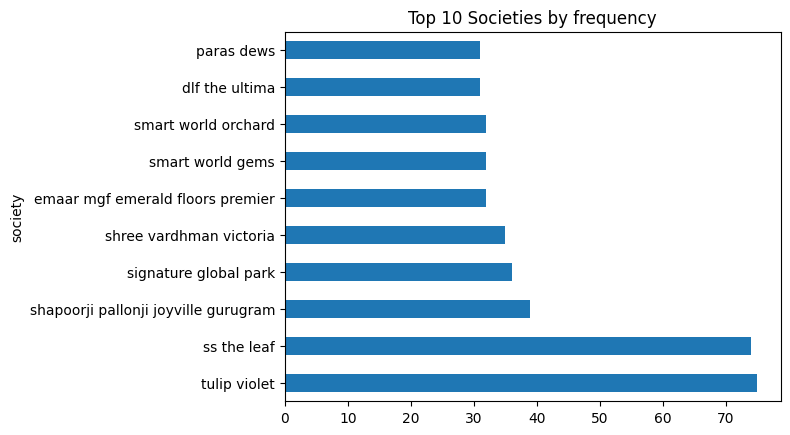

In [26]:
df['society'].value_counts().head(10).plot(kind='barh', title='Top 10 Societies by frequency')

<Axes: title={'center': 'Top 10 Sectors by frequency'}, xlabel='sector'>

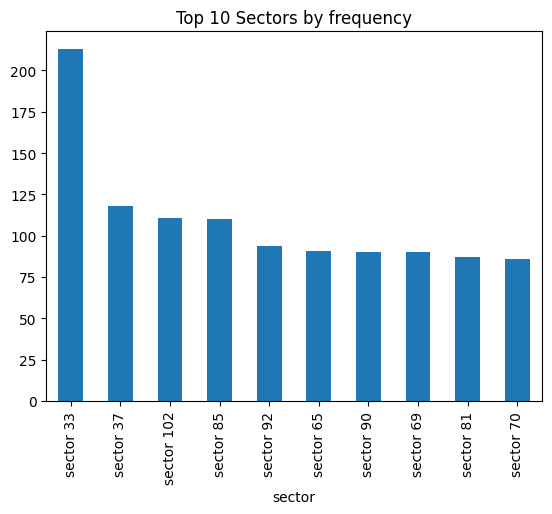

In [27]:
df['sector'].value_counts().head(10).plot(kind='bar', title='Top 10 Sectors by frequency')

<Axes: xlabel='price_cr', ylabel='Count'>

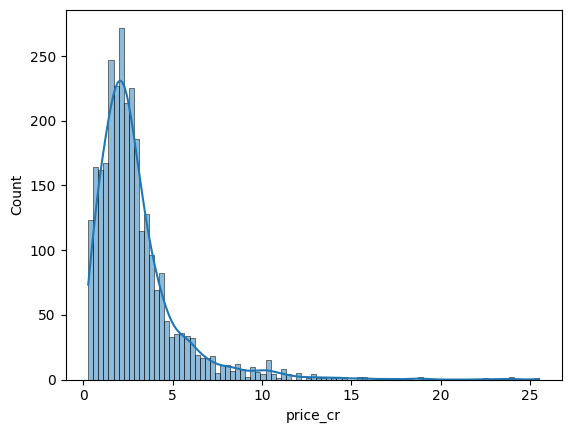

In [28]:
sns.histplot(df['price_cr'], kde=True)

In [29]:
print("Price Skewness: ", df['price_cr'].skew())

Price Skewness:  2.9571121734697465


In [30]:
print("Price Kurtosis: ", df['price_cr'].kurt())

Price Kurtosis:  14.60125502789868


In [31]:
quantiles = df['price_cr'].quantile([0.01, 0.1, 0.25, 0.50, 0.75, 0.90, 0.99])
quantiles

0.01     0.408
0.10     0.850
0.25     1.530
0.50     2.380
0.75     3.553
0.90     5.525
0.99    11.900
Name: price_cr, dtype: float64

In [32]:
#50% flats are below 1.4 Crore Rupees

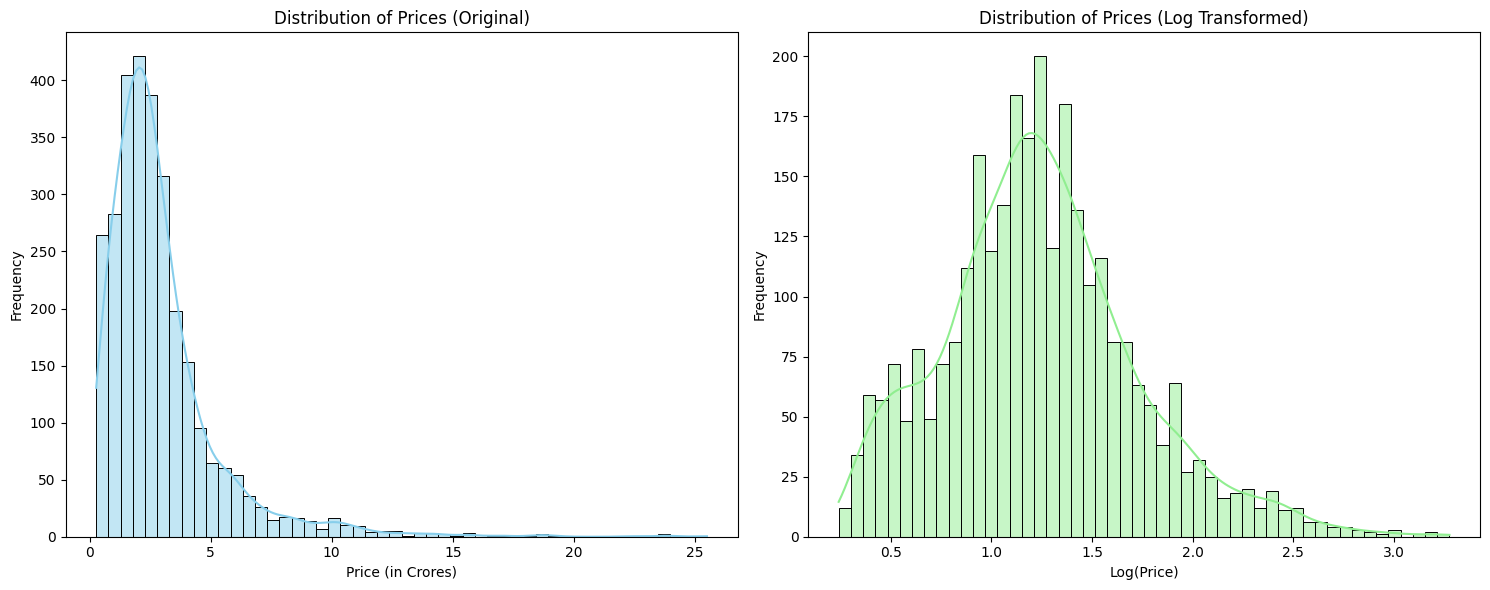

In [33]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price_cr'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price_cr']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

<Axes: xlabel='price_cr'>

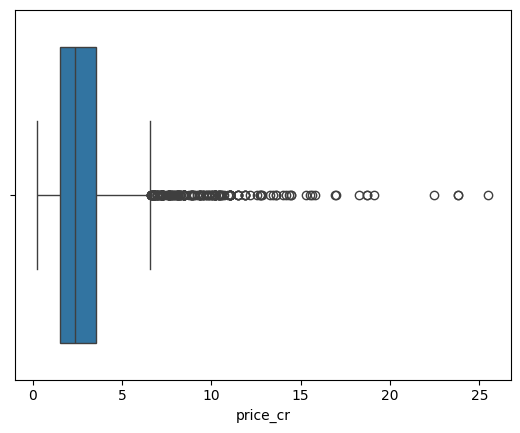

In [34]:
sns.boxplot(x=df['price_cr'])

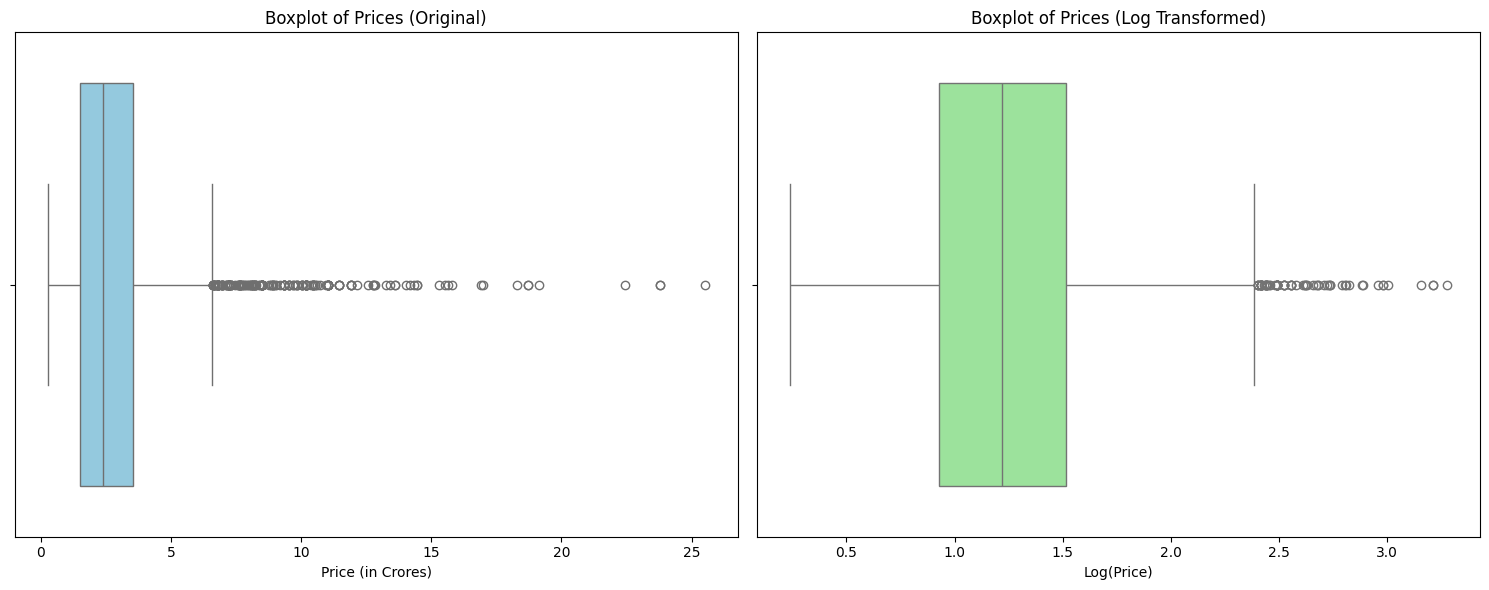

In [35]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(x=df['price_cr'], color='skyblue')
plt.title('Boxplot of Prices (Original)')
plt.xlabel('Price (in Crores)')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(x=np.log1p(df['price_cr']), color='lightgreen')
plt.title('Boxplot of Prices (Log Transformed)')
plt.xlabel('Log(Price)')

plt.tight_layout()
plt.show()

<Axes: title={'center': '#Flats for each bhk type'}, ylabel='bedroom'>

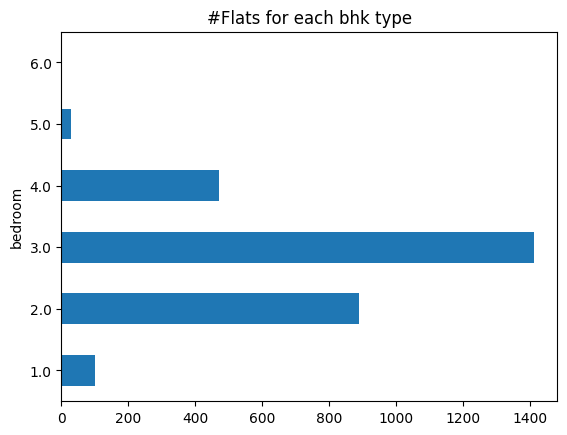

In [36]:
df['bedroom'].value_counts().sort_index().plot(kind='barh', title='#Flats for each bhk type')

<Axes: title={'center': '#Flats for each bathroom type'}, ylabel='bathroom'>

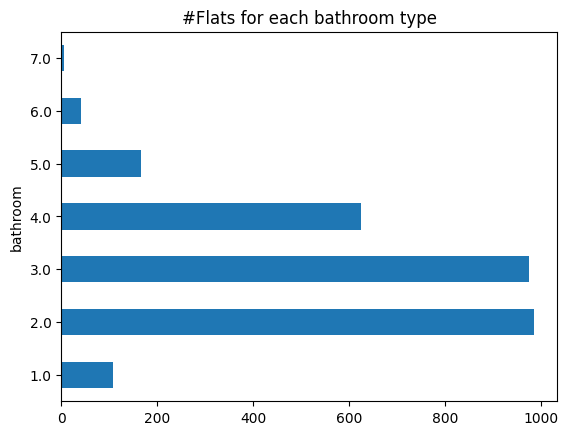

In [37]:
df['bathroom'].value_counts().sort_index().plot(kind='barh', title='#Flats for each bathroom type')

<Axes: title={'center': '#bathroom proportion'}, ylabel='proportion'>

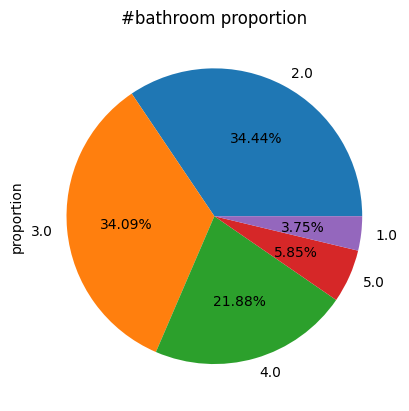

In [38]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%',
                                                        title='#bathroom proportion')

<Axes: title={'center': '#Flats for each balcony type'}, ylabel='balcony'>

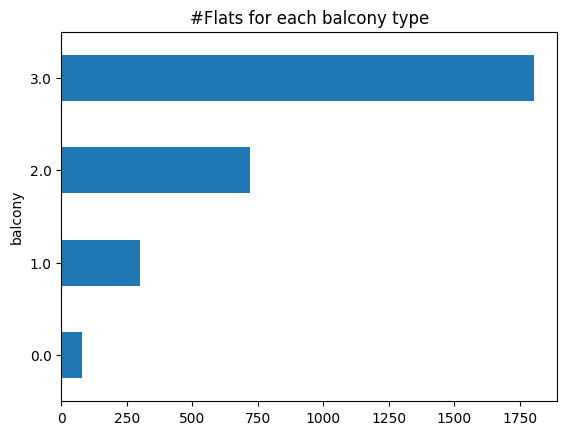

In [39]:
df['balcony'].value_counts().sort_index().plot(kind='barh', title='#Flats for each balcony type')

<Axes: xlabel='floor_rise'>

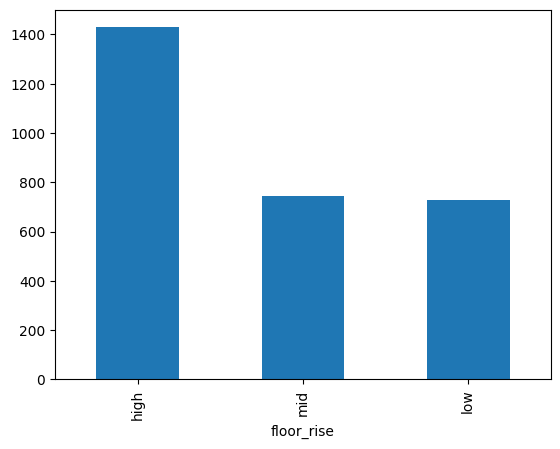

In [40]:
df['floor_rise'].value_counts().plot(kind='bar')

<Axes: ylabel='age'>

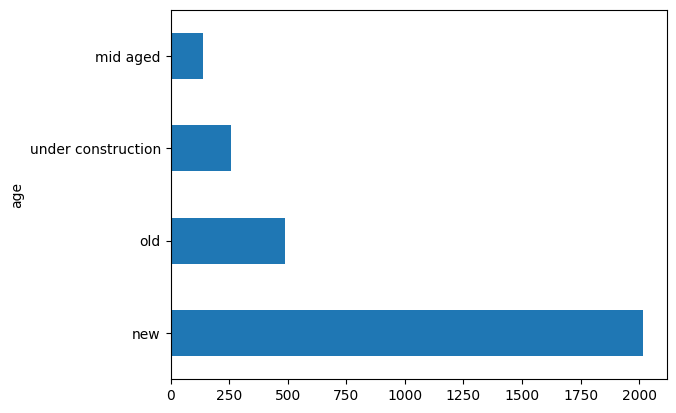

In [41]:
df['age'].value_counts().plot(kind='barh')

<Axes: ylabel='area_sqm'>

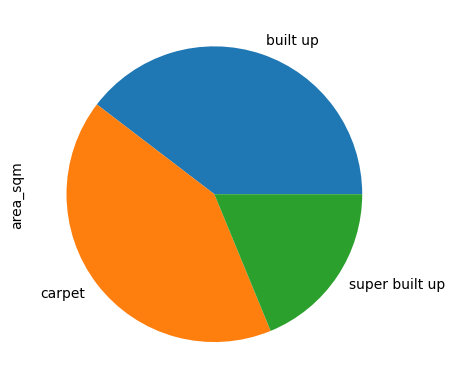

In [42]:
df.groupby('area_type')['area_sqm'].mean().plot(kind='pie')

In [43]:
#from ydata_profiling import ProfileReport
#profile = ProfileReport(df, title='Pandas Profiling Report', explorative=True)
#profile.to_file('10_df_profiling.html')


In [44]:
'''
profile = ProfileReport(
    df,
    title="10_df_profiling",
    dataset={
        "description": "99 Acres Dataset Description",
        "author": "Gaurav Singh",
    },
    variables={
        "descriptions": {
            "col1": "Description of all columns",
        }
    },
    explorative=True,   # deeper analysis
    minimal=False,      # set True for large datasets
)
profile.to_file("10_df_profiling.html")
'''

'\nprofile = ProfileReport(\n    df,\n    title="10_df_profiling",\n    dataset={\n        "description": "99 Acres Dataset Description",\n        "author": "Gaurav Singh",\n    },\n    variables={\n        "descriptions": {\n            "col1": "Description of all columns",\n        }\n    },\n    explorative=True,   # deeper analysis\n    minimal=False,      # set True for large datasets\n)\nprofile.to_file("10_df_profiling.html")\n'

[Summarizing dataframe]                      |          | [  0%]   00:00 -> (? left)

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)



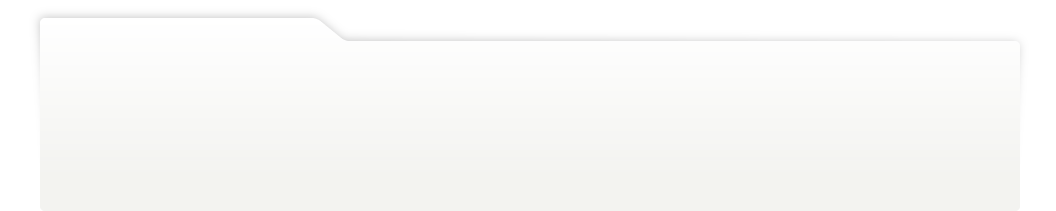
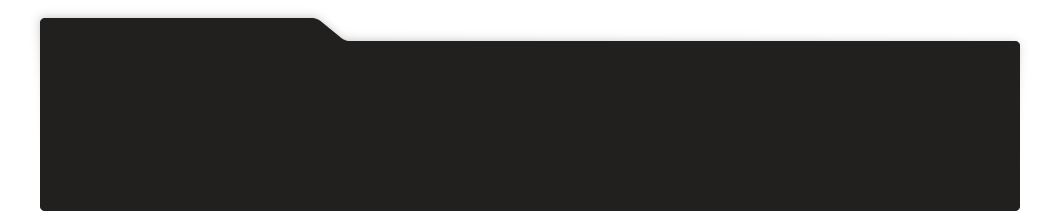
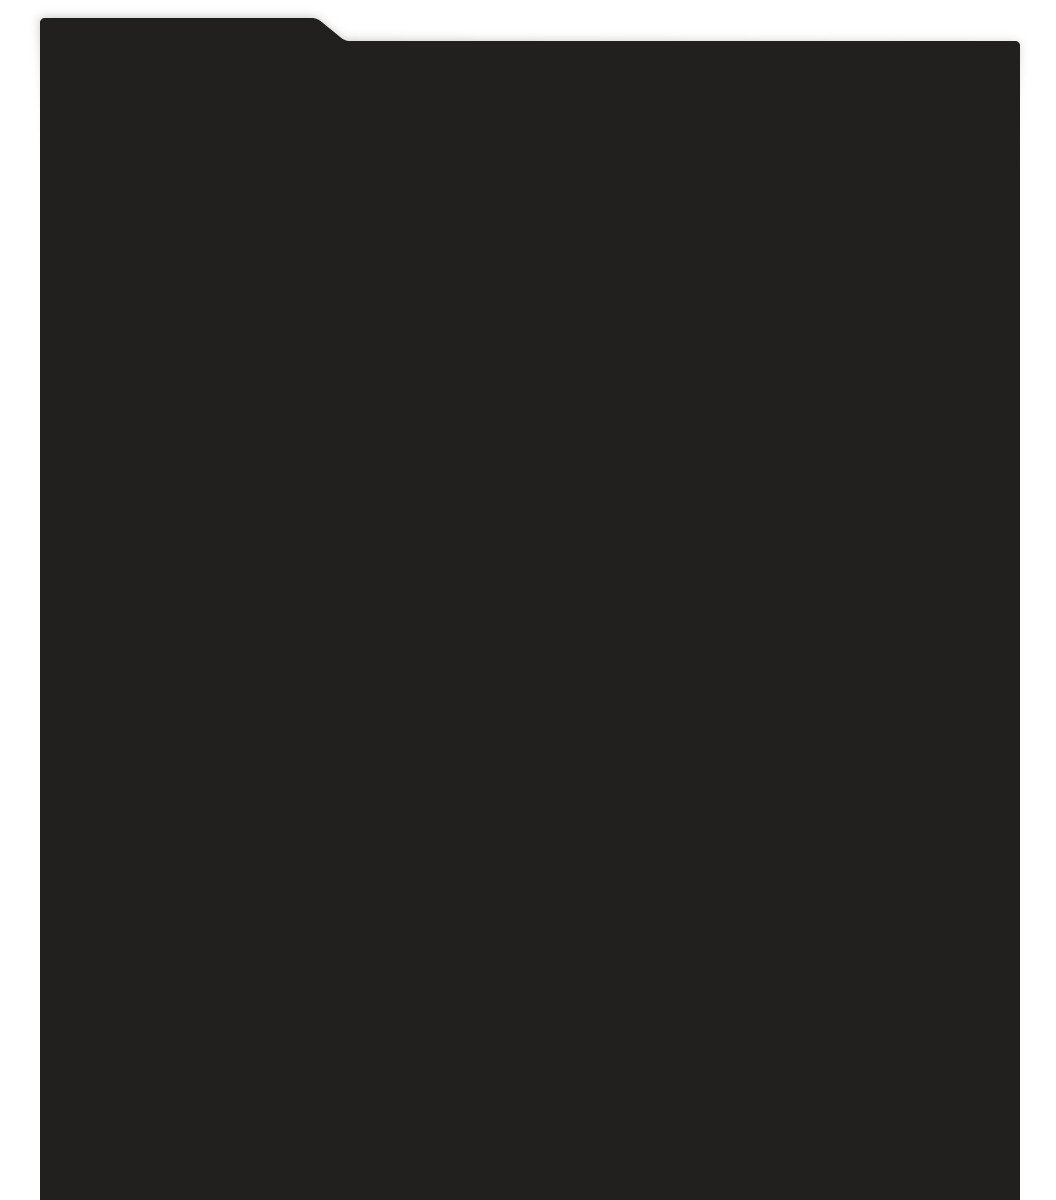
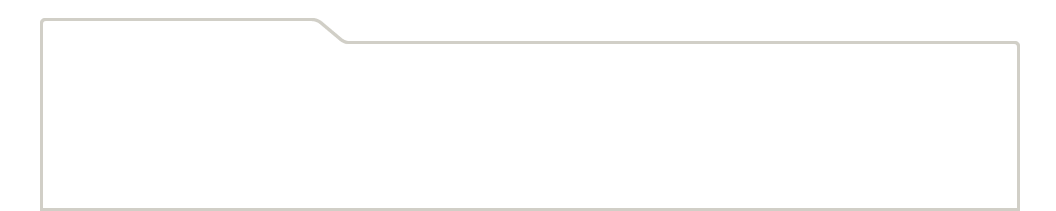
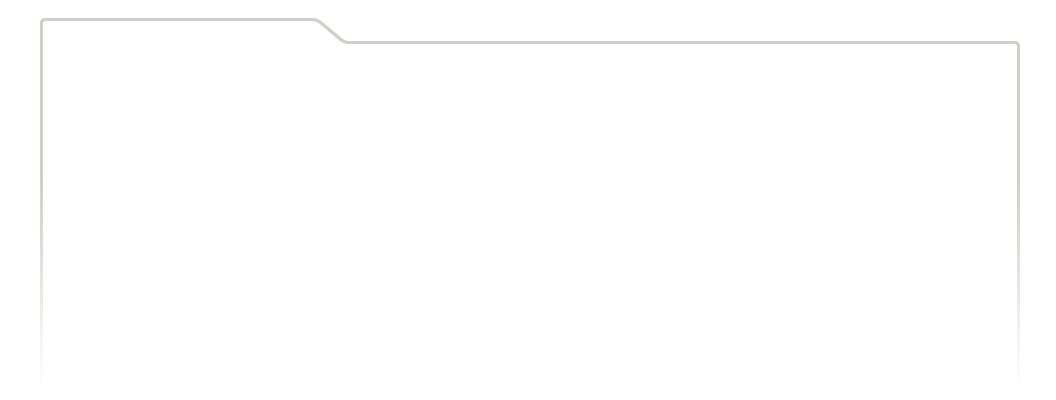
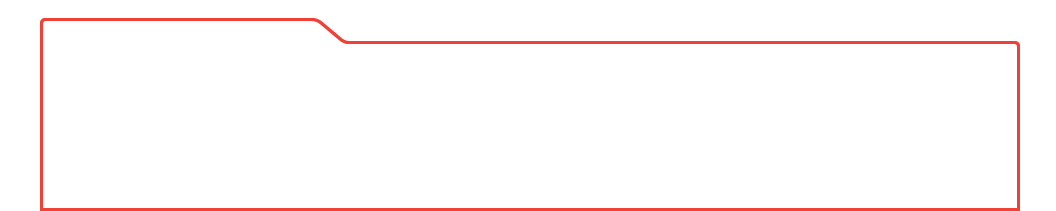
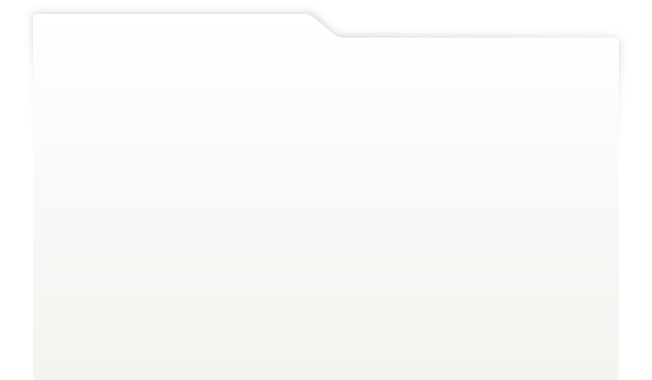
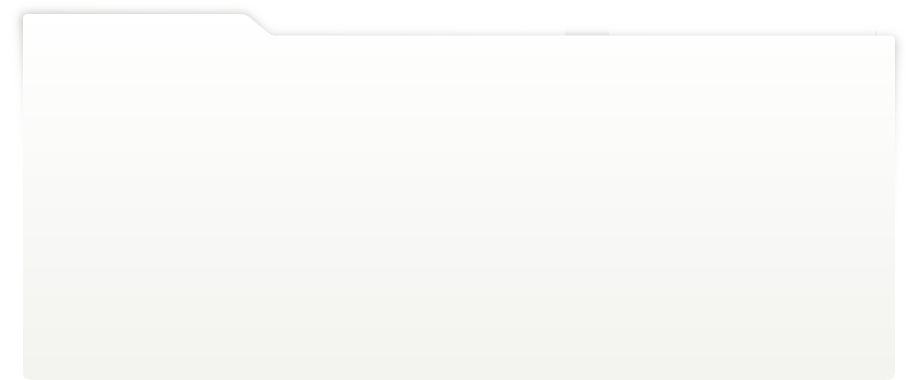
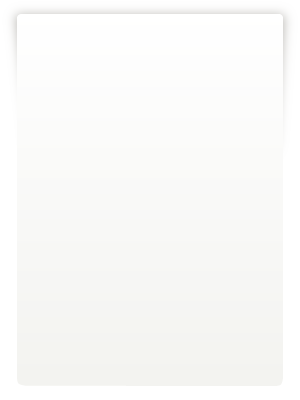
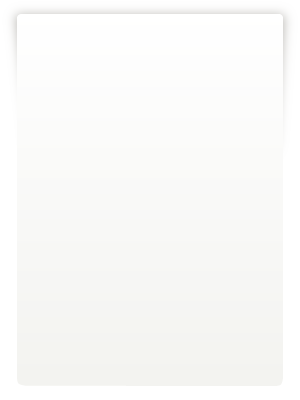
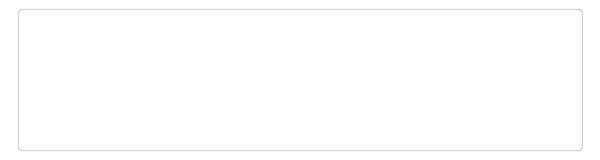
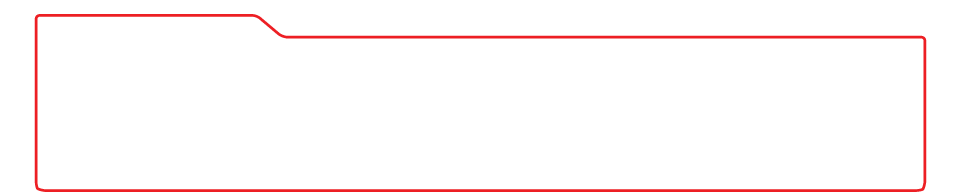
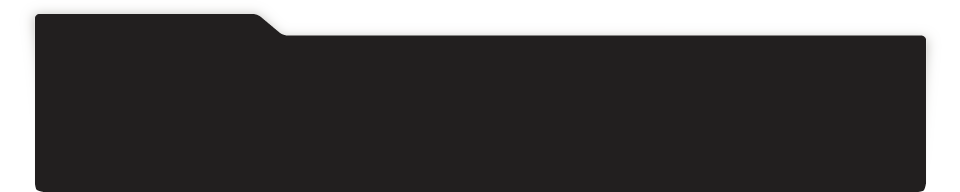
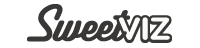
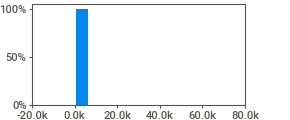
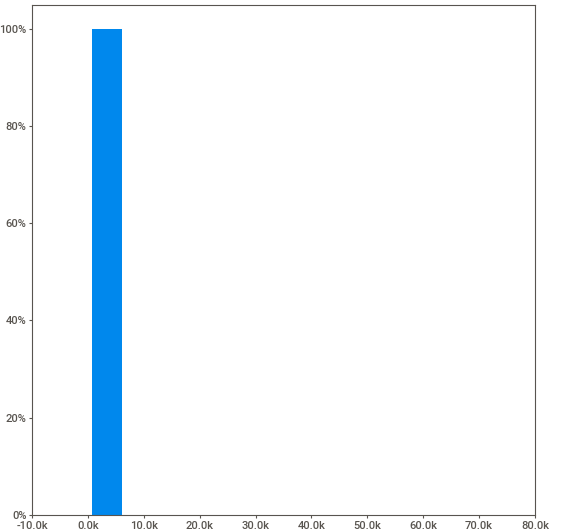
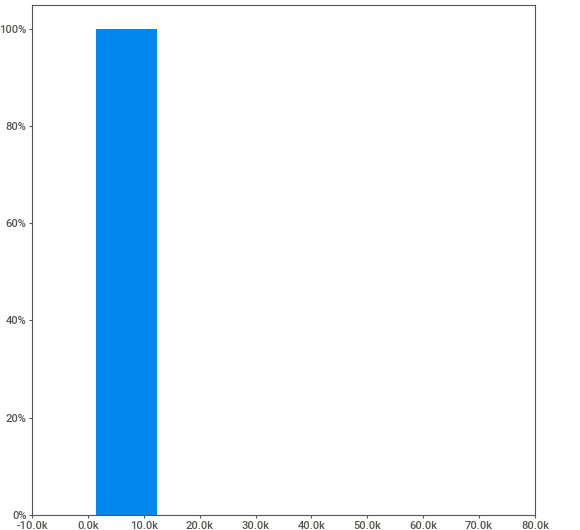
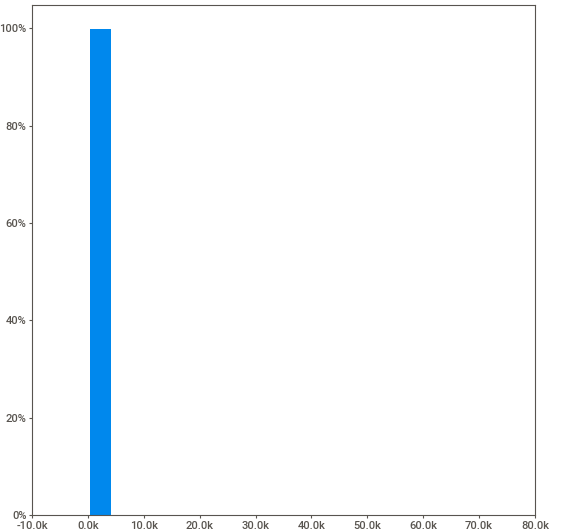
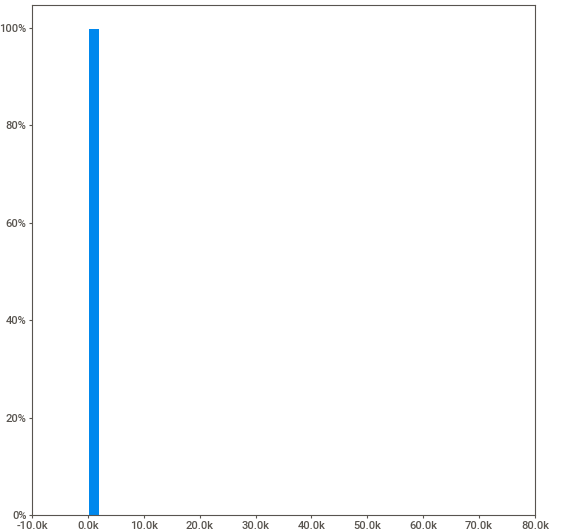
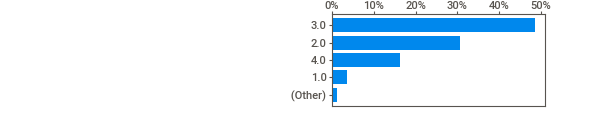
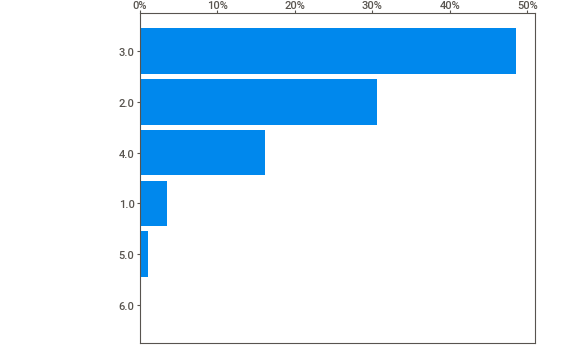
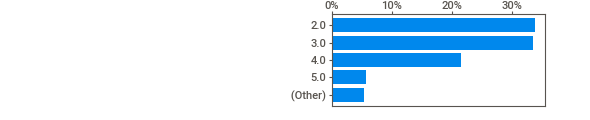
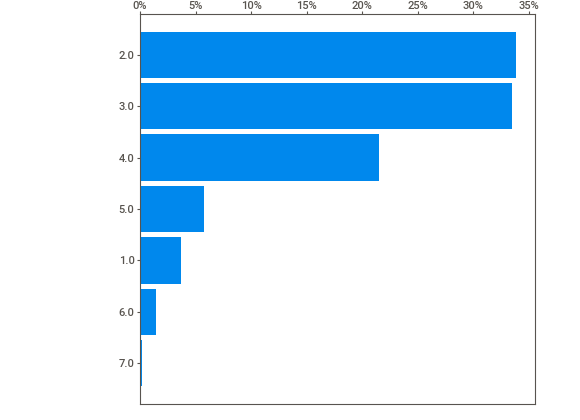
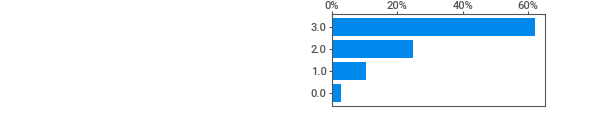
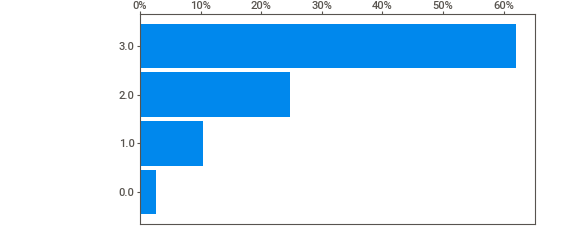
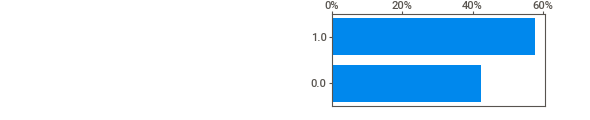
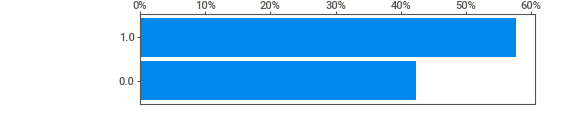
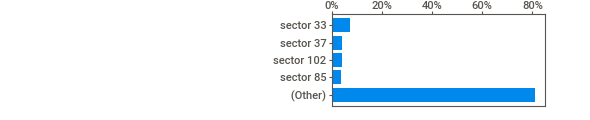
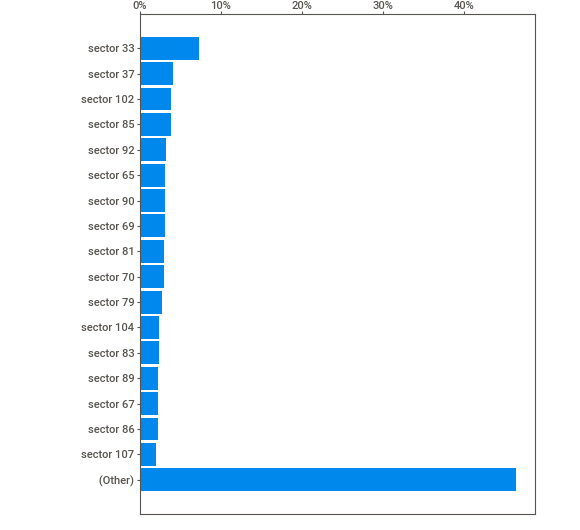
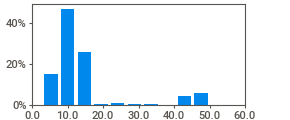
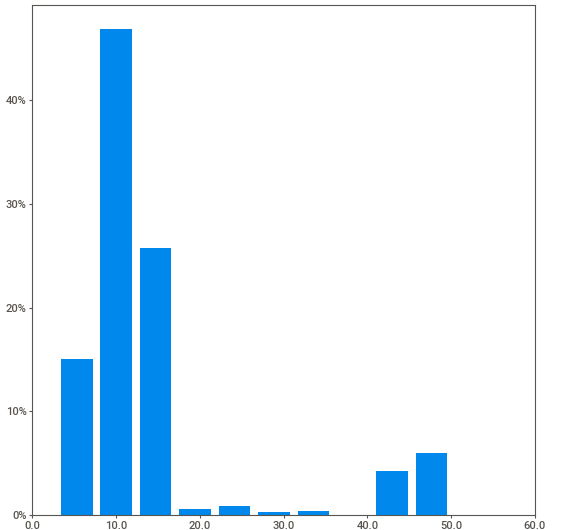
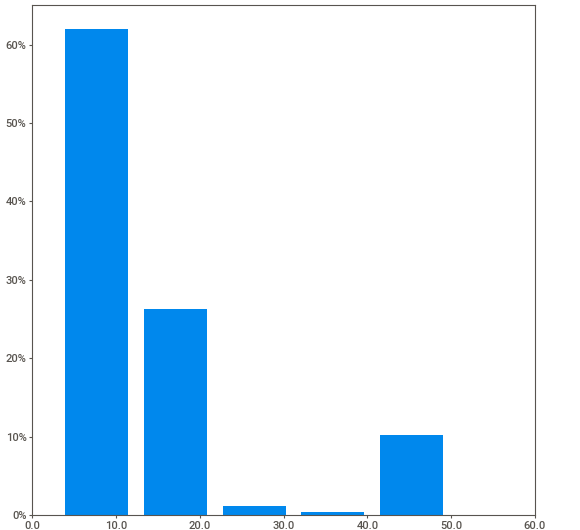
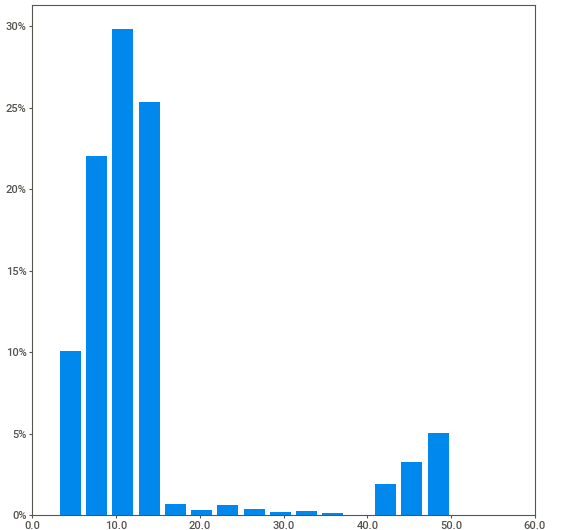
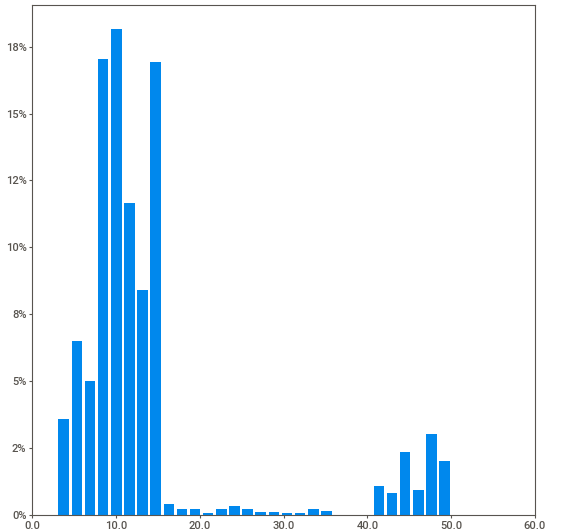
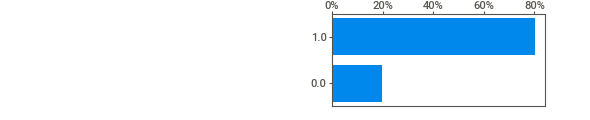
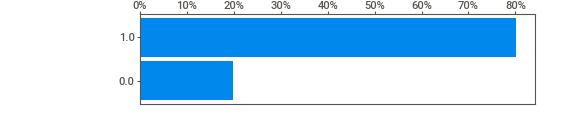
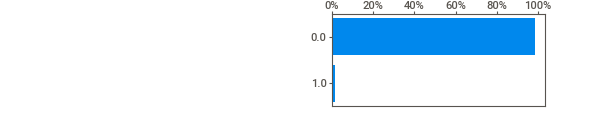
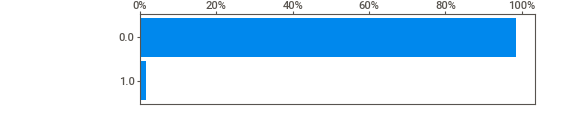
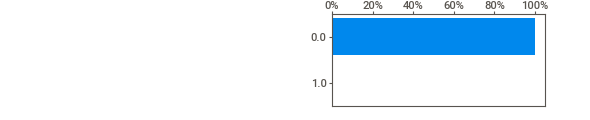
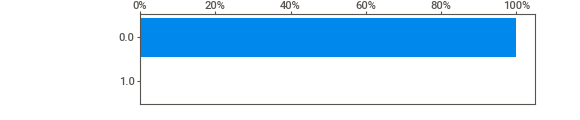
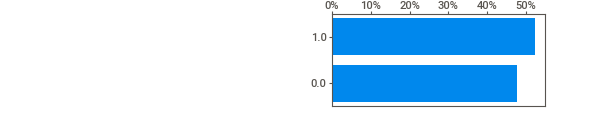
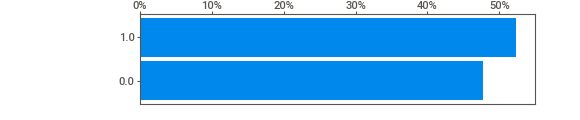
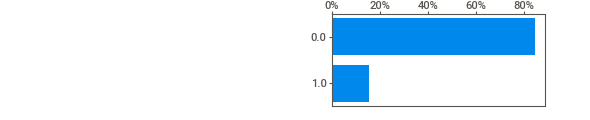
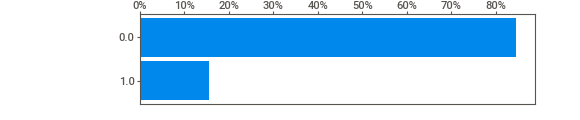
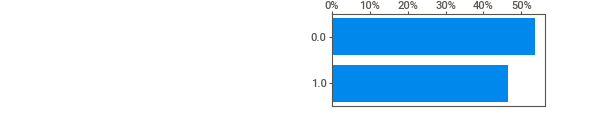
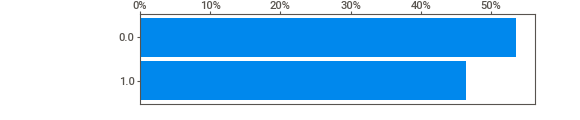
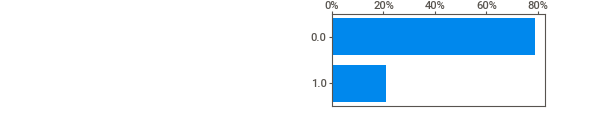
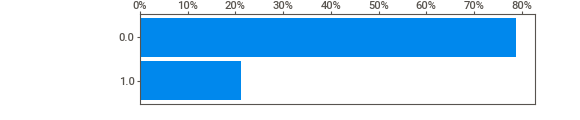
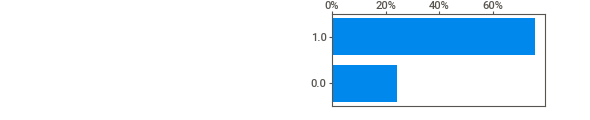
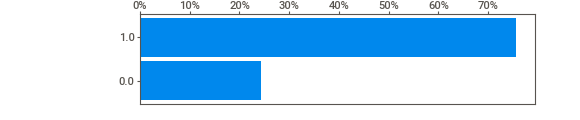
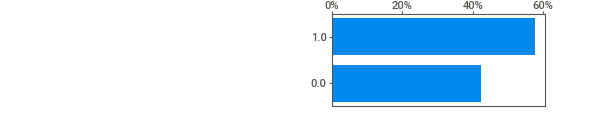
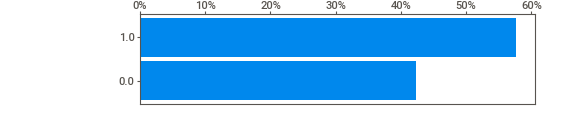
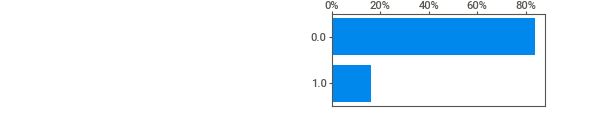
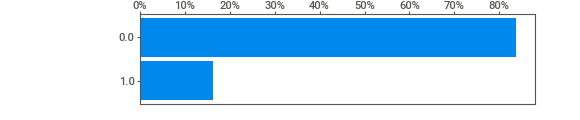
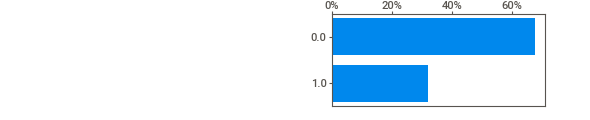
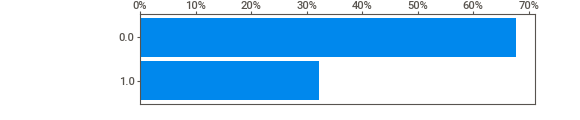
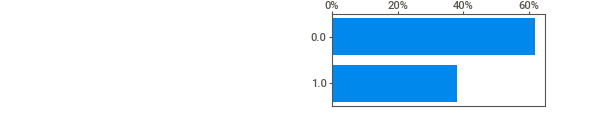
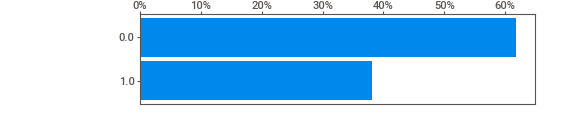
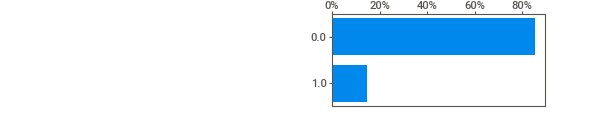
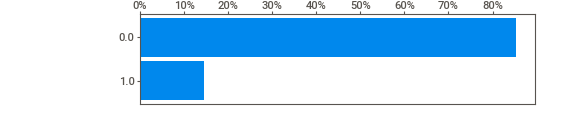
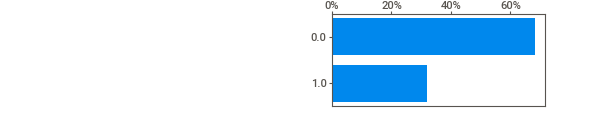
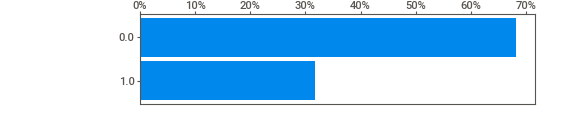
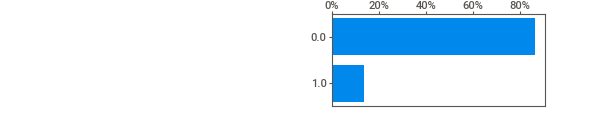
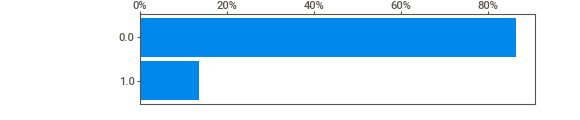
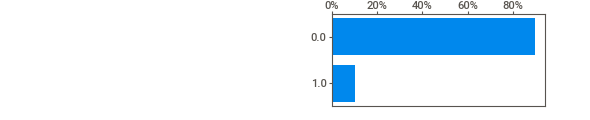
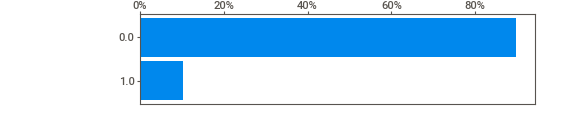
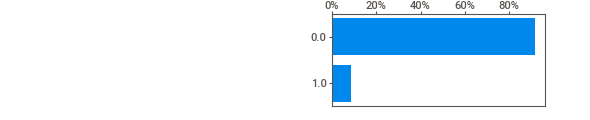
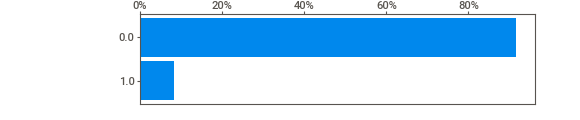
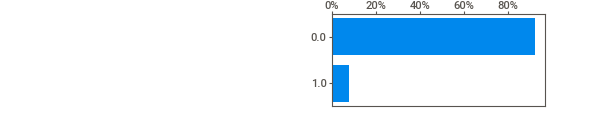
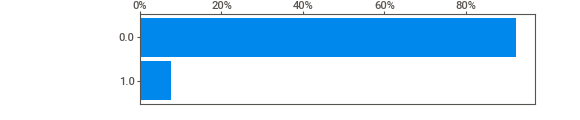
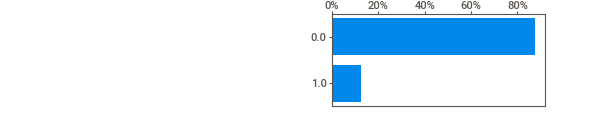
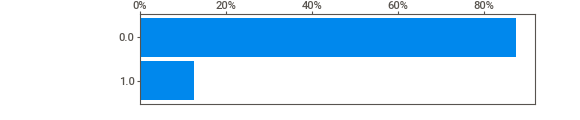
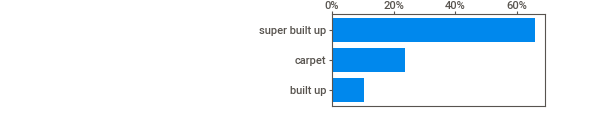
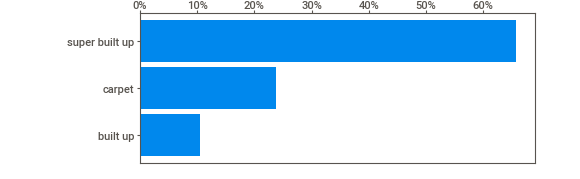
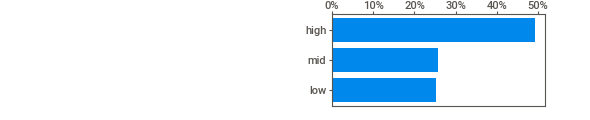
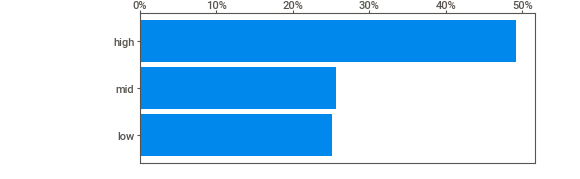
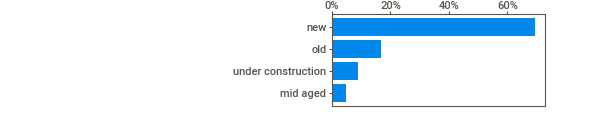
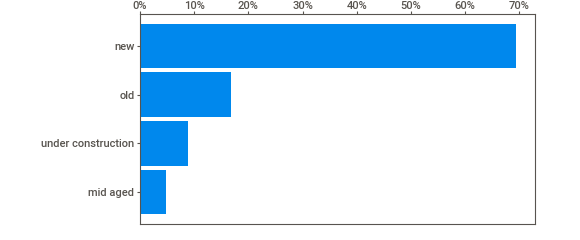
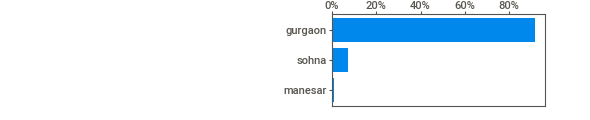
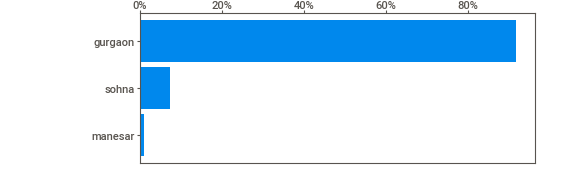
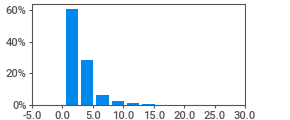
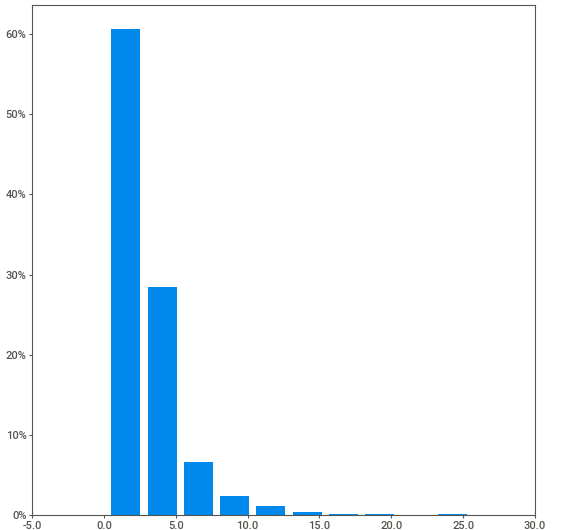
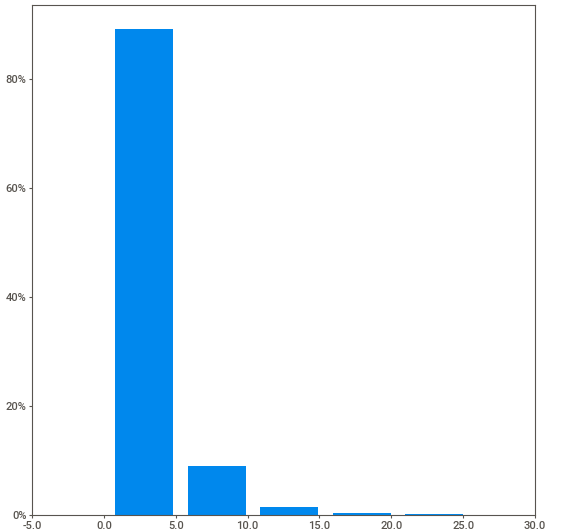
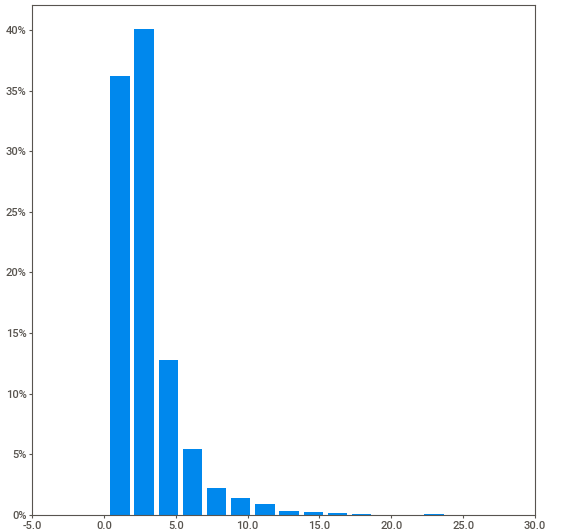
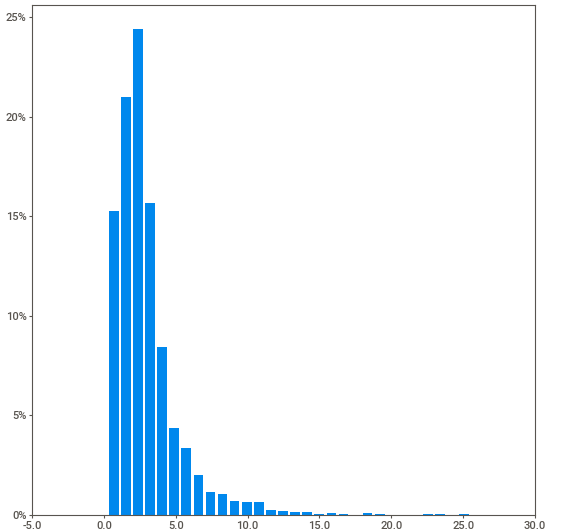
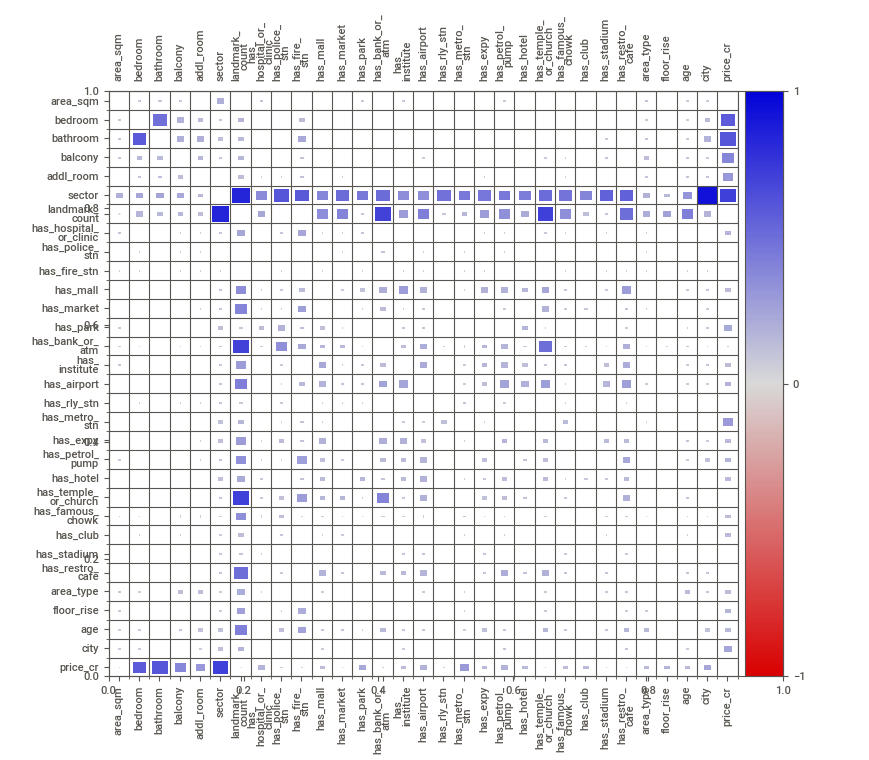
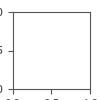

In [45]:
report = sv.analyze(df)
report.show_notebook()